# ABSA with T5 + LoRA and XAI Visualization
This code implements an end-to-end T5+LoRA-based Aspect-Based Sentiment Analysis (ABSA) model training and interpretability workflow: first, the CSV files from the SemEval2014 dataset are loaded and filtered using DataLoaderPreprocessor, sentences, aspect words, and their positions are extracted, and they are converted into a list of records; then, the text is segmented, and construct BIO annotation sequences and sentiment labels in a custom ABSADataset, while organising batch iterations through DataLoader. Next, load the T5ForConditionalGeneration model and apply the LoRA adapter to reduce the number of parameters during fine-tuning, then define ABSAHead to perform BIO annotation and sentiment classification prediction on the model's hidden layer outputs, and combine with the cross-entropy loss function to achieve joint training; during training, use torch.cuda.amp for mixed-precision training to improve efficiency, and accumulate prediction results with ground truth labels to calculate BIO F1 and sentiment classification accuracy; after training, use Matplotlib to plot confusion matrices for sentiment classification and BIO annotation to visually assess model performance; finally, use LIME to provide local interpretability for sentiment predictions of single sentence inputs, and analyse the impact of key words on predictions for specific categories.

In [12]:
import sys
!{sys.executable} -m pip install --upgrade "huggingface-hub>=0.30.0,<1.0" transformers
import warnings
warnings.filterwarnings("ignore", message="h5py is running against HDF5")


In [36]:
import glob
import warnings
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report
from transformers import AutoTokenizer, T5ForConditionalGeneration
from peft import get_peft_model, LoraConfig, TaskType
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ========== Configuration Parameters ==========
CSV_GLOB     = r"E:/ABSA-LLM-XAI/dataset/SemEval2014/**/*.csv"
TEXT_COL     = "Sentence"
ASPECT_COL   = "Aspect Term"
LABEL_COL    = "polarity"
MAX_LEN      = 128
BATCH_SIZE   = 8
EPOCHS       = 15
LR           = 2e-4
BACKBONE     = "t5-base"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
ENABLE_XAI_VIS = True
warnings.filterwarnings("ignore")

## Data Loading and Preprocessing

In [37]:
class DataLoaderPreprocessor:
    def load_files(self, paths):
        """
        Loads and filters CSV files from the provided list of file paths.

        Parameters:
            paths (list[str]): File paths matching the CSV_GLOB pattern (may include wildcards).

        Returns:
            pd.DataFrame: A single DataFrame concatenating all valid CSVs with the required columns.

        Raises:
            FileNotFoundError: If no CSV files with the required columns are found.
        """
        dfs = []  # List to accumulate DataFrames from each valid CSV
        for p in paths:
            try:
                # Read the CSV file into a DataFrame
                df = pd.read_csv(p)
                # Check that the DataFrame contains the required columns
                if all(c in df.columns for c in [TEXT_COL, ASPECT_COL, LABEL_COL]):
                    # Select only the needed columns and store
                    dfs.append(df[[TEXT_COL, ASPECT_COL, LABEL_COL]])
            except Exception:
                # Skip files that fail to load or lack proper format
                continue

        if not dfs:
            # No valid files were loaded
            raise FileNotFoundError("No valid CSV files.")
        # Concatenate all collected DataFrames into one, resetting the index
        return pd.concat(dfs, ignore_index=True)

def load_records():
    """
    Transforms the raw DataFrame into a list of record dictionaries,
    each containing the sentence, aspect span, and sentiment polarity.

    Returns:
        List[Dict]: Processed records ready for model input.
    """
    # Load all CSV files matching the pattern
    df = DataLoaderPreprocessor().load_files(glob.glob(CSV_GLOB, recursive=True))

    # Compute the character index where the aspect term begins in each sentence
    df["from"] = df.apply(
        lambda r: r[TEXT_COL].lower().find(r[ASPECT_COL].lower()), 
        axis=1
    )
    # Compute the character index where the aspect term ends
    df["to"] = df["from"] + df[ASPECT_COL].str.len()

    rec = []  # List to hold cleaned record dictionaries
    for _, r in df.iterrows():
        # Include only those rows where the aspect term was found
        if r["from"] >= 0:
            rec.append({
                "Sentence": r[TEXT_COL],          # Original sentence text
                "from_": int(r["from"]),         # Start index of the aspect term
                "to": int(r["to"]),              # End index of the aspect term
                "polarity": r[LABEL_COL].lower() # Sentiment label, normalized to lowercase
            })
    return rec

# Execute the record-loading pipeline
records = load_records()

# Extract and sort unique sentiment labels
label_set = sorted({r["polarity"] for r in records})
# Create a mapping from label string to numeric ID
pol2id    = {lab: idx for idx, lab in enumerate(label_set)}
# Number of sentiment classes
NUM_SENT  = len(pol2id)

# Print a summary of loaded records and label-to-ID mapping
print(f"Loaded {len(records)} records, labels: {pol2id}")


Loaded 6196 records, labels: {'conflict': 0, 'negative': 1, 'neutral': 2, 'positive': 3}


## Dataset and DataLoader

In [38]:
# Load the pre-trained tokenizer for the specified backbone model
tok = AutoTokenizer.from_pretrained(BACKBONE)

class ABSADataset(Dataset):
    def __init__(self, recs):
        """
        Initialize the dataset with a list of raw records.

        Parameters:
            recs (List[Dict]): Each record contains:
                - "Sentence": the input text
                - "from_": start index of the aspect term
                - "to": end index of the aspect term
                - "polarity": sentiment label
        Action:
            Tokenize and encode each record immediately and store in self.data.
        """
        self.data = [self.encode(r) for r in recs]

    def encode(self, r):
        """
        Tokenize a single record and build its label tensors.

        Steps:
        1. Tokenize the sentence to obtain input IDs, attention mask, and offset mappings.
        2. Construct a BIO label sequence aligned with token offsets:
           - -100 for padding tokens (ignored by the loss)
           - 1 for the beginning token of the aspect span
           - 2 for inside tokens of the aspect span
           - 0 for all other tokens
        3. Map the string polarity to its numeric ID.

        Returns:
            dict: Contains
              - input_ids, attention_mask, etc.
              - labels_bio: list of BIO labels
              - labels_sent: integer sentiment label
        """
        # Tokenize and get character offsets for each token
        enc = tok(
            r["Sentence"],
            return_offsets_mapping=True,
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN
        )
        offsets = enc.pop("offset_mapping")  # Remove offsets from the dict for manual processing

        # Create BIO labels based on character-level aspect span
        bio = []
        for start, end in offsets:
            if start == end == 0:
                # Padding token (no real text) → use -100 to mask out in loss computation
                bio.append(-100)
            elif start >= r["from_"] and end <= r["to"]:
                # Token is inside the aspect term span
                # Use 1 for the first token in the span, 2 for subsequent tokens
                bio.append(1 if start == r["from_"] else 2)
            else:
                # Token is outside the aspect span
                bio.append(0)

        # Attach the BIO labels and the overall sentiment label
        enc["labels_bio"]  = bio
        enc["labels_sent"] = pol2id[r["polarity"]]

        return enc

    def __len__(self):
        """
        Return the total number of encoded examples.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Fetch the example at index idx, converting all fields to torch tensors.

        Returns:
            Dict[str, torch.Tensor]: A batch-ready data example.
        """
        item = self.data[idx]
        return {k: torch.tensor(v) for k, v in item.items()}

# Instantiate the dataset and wrap it in a DataLoader for batching
dataset = ABSADataset(records)
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True  # Shuffle data every epoch for better training dynamics
)

print("module complete")


module complete


## Model Setup with LoRA

In [39]:
# Load the pre-trained T5 model for sequence-to-sequence generation
base = T5ForConditionalGeneration.from_pretrained(BACKBONE)

# Configure LoRA (Low-Rank Adaptation) for parameter-efficient fine-tuning
# - task_type: sequence-to-sequence language modeling
# - r: low-rank dimension
# - lora_alpha: scaling factor
# - lora_dropout: dropout probability applied to the low-rank adapters
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1
)

# Wrap the base model with the LoRA adapters and move it to the chosen device (GPU or CPU)
base = get_peft_model(base, lora_cfg).to(DEVICE)

class ABSAHead(nn.Module):
    """
    Custom classification head for Aspect-Based Sentiment Analysis (ABSA).

    This head produces:
      - BIO token-level logits for aspect-term extraction (3 classes: B, I, O)
      - Sentence-level sentiment logits for overall polarity classification
    """
    def __init__(self, dim, num_cls):
        """
        Initialize the ABSA head.

        Parameters:
            dim (int): Hidden dimension size from the transformer backbone
            num_cls (int): Number of sentiment classes
        """
        super().__init__()
        # Linear layer to predict BIO labels (Begin, Inside, Outside) for each token
        self.bio = nn.Linear(dim, 3)
        # Linear layer to predict overall sentiment from the pooled representation
        self.sent = nn.Linear(dim, num_cls)
        # Loss for BIO tagging, ignoring padding tokens marked with -100
        self.lb = nn.CrossEntropyLoss(ignore_index=-100)
        # Loss for sentiment classification
        self.ls = nn.CrossEntropyLoss()

    def forward(self, hid, mask, yb=None, ys=None):
        """
        Forward pass through the ABSA head.

        Parameters:
            hid (Tensor): Hidden states from the transformer (batch_size x seq_len x dim)
            mask (Tensor): Attention mask (batch_size x seq_len), with 1s for real tokens
            yb (Tensor, optional): True BIO labels (batch_size x seq_len)
            ys (Tensor, optional): True sentiment labels (batch_size,)

        Returns:
            dict: {
                "bio_logits": Tensor of shape (batch_size x seq_len x 3),
                "sent_logits": Tensor of shape (batch_size x num_cls),
                "loss": Combined loss (if yb and ys are provided)
            }
        """
        # Compute a mean-pooled sentence representation, masking out padding tokens
        pooled = (hid * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True)

        # Token-level logits for BIO tagging
        bio_logits = self.bio(hid)
        # Sentence-level logits for sentiment classification
        sent_logits = self.sent(pooled)

        out = {
            "bio_logits": bio_logits,
            "sent_logits": sent_logits
        }

        # If ground-truth labels are provided, compute and sum the two losses
        if yb is not None and ys is not None:
            # Flatten BIO logits and labels for token-level loss
            loss_b = self.lb(
                bio_logits.view(-1, 3),
                yb.view(-1)
            )
            # Sentence-level classification loss
            loss_s = self.ls(sent_logits, ys)
            # Combine losses (you may weight them differently if desired)
            out["loss"] = loss_b + loss_s

        return out

# Instantiate the ABSA head with the model's hidden size and number of sentiment classes
head = ABSAHead(
    dim=base.config.d_model,
    num_cls=NUM_SENT
).to(DEVICE)

# Create the optimizer, updating both the base model and the ABSA head parameters
optim = torch.optim.Adam(
    list(base.parameters()) + list(head.parameters()),
    lr=LR
)

print("module complete")


module complete


## Training Loop

In [40]:
from torch.cuda.amp import autocast, GradScaler  # Import mixed-precision utilities

# Initialize a gradient scaler for automatic loss scaling in mixed precision
scaler = GradScaler()

# Lists to record training history: losses, BIO F1 scores, and sentiment accuracies
h_losses, h_f1s, h_accs = [], [], []

# Lists to accumulate all true and predicted labels across batches for evaluation
true_s_all, pred_s_all = [], []
true_b_all, pred_b_all = [], []

# Main training loop over epochs
for epoch in range(EPOCHS):
    # Iterate through mini-batches from the DataLoader
    for batch in loader:
        # Move input IDs and attention masks to the selected device (GPU/CPU)
        ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
        # Move BIO labels and sentiment labels to device
        yb, ys    = batch['labels_bio'].to(DEVICE), batch['labels_sent'].to(DEVICE)

        optim.zero_grad()  # Zero out gradients before backpropagation

        # Automatic mixed-precision context for faster training and reduced memory
        with autocast():
            # Forward pass through the encoder to get hidden states
            enc  = base.encoder(input_ids=ids, attention_mask=mask, return_dict=True)
            # Forward pass through the ABSA head to get logits and loss
            out  = head(enc.last_hidden_state, mask, yb, ys)
            loss = out['loss']  # Combined BIO + sentiment loss

        # Scale the loss, backpropagate, and step the optimizer in FP16
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()

        # Collect sentiment predictions and true labels for accuracy
        pred_s_all.extend(out['sent_logits'].argmax(-1).cpu().numpy())
        true_s_all.extend(ys.cpu().numpy())

        # Collect BIO tag predictions and true labels, filtering out padding tokens (-100)
        pb = out['bio_logits'].argmax(-1).view(-1).cpu().numpy()
        tb = yb.view(-1).cpu().numpy()
        mask_keep = tb != -100
        pred_b_all.extend(pb[mask_keep])
        true_b_all.extend(tb[mask_keep])

    # After each epoch, record the final batch loss
    h_losses.append(loss.item())
    # Compute macro-averaged F1 for the BIO tag task
    h_f1s.append(f1_score(true_b_all, pred_b_all, average='macro'))
    # Compute overall accuracy for the sentiment classification task
    h_accs.append(accuracy_score(true_s_all, pred_s_all))

print("Mixed precision training complete.")



Mixed precision training complete.


In [1]:
report = classification_report(true_s_all, pred_s_all, digits=4)
print(report)

              precision    recall  f1-score   support

           0     0.7010    0.2966    0.4168      2040
           1     0.7939    0.8683    0.8295     25575
           2     0.7493    0.5938    0.6625     16605
           3     0.8811    0.9214    0.9008     48720

    accuracy                         0.8345     92940
   macro avg     0.7813    0.6700    0.7024     92940
weighted avg     0.8296    0.8345    0.8280     92940



## Evaluation Report Visualization

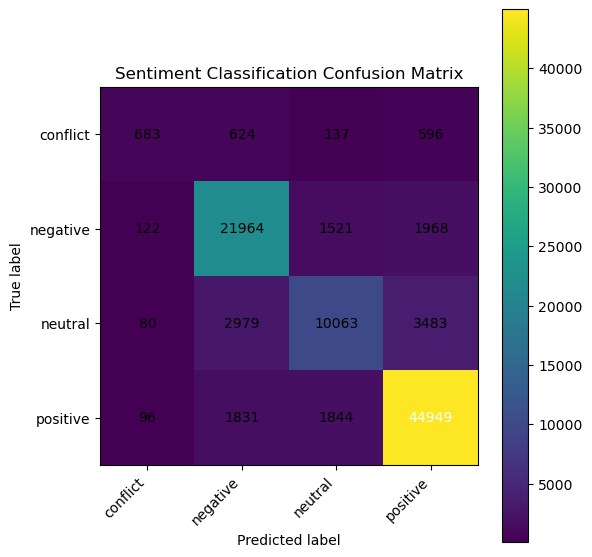

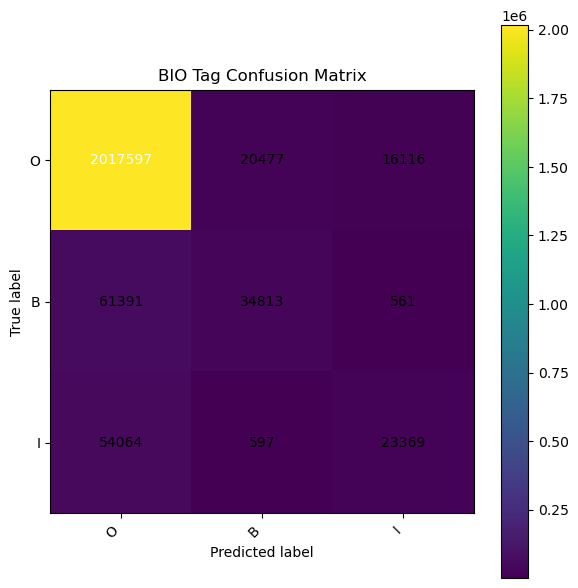

In [48]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Plot a confusion matrix:
      - y_true: list of true labels
      - y_pred: list of predicted labels
      - labels: list of class names (in the order corresponding to the encoded values in y_true/y_pred)
      - title:  title of the plot
    """
    # Compute the confusion matrix; rows correspond to true labels and columns to predicted labels
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    
    # Create a figure and axis for the plot
    fig, ax = plt.subplots(figsize=(6, 6))
    # Display the confusion matrix as an image
    im = ax.imshow(cm, interpolation='nearest')
    # Add a colorbar to indicate scale
    fig.colorbar(im, ax=ax)
    
    # Set tick locations and labels on both axes
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    # Rotate x-axis labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    ax.set_title(title)
    
    # Annotate each cell with the count; use white text on dark cells, black text on light cells
    thresh = cm.max() / 2
    for i in range(len(labels)):
        for j in range(len(labels)):
            color = 'white' if cm[i, j] > thresh else 'black'
            ax.text(j, i, f"{cm[i, j]}", ha='center', va='center', color=color)
    
    # Adjust layout to prevent clipping of labels
    fig.tight_layout()
    plt.show()

# Plot confusion matrix for sentiment classification
plot_confusion_matrix(
    true_s_all, pred_s_all,
    labels=label_set,
    title='Sentiment Classification Confusion Matrix'
)

# Plot confusion matrix for BIO tagging
plot_confusion_matrix(
    true_b_all, pred_b_all,
    labels=['O', 'B', 'I'],
    title='BIO Tag Confusion Matrix'
)



## Training Curves

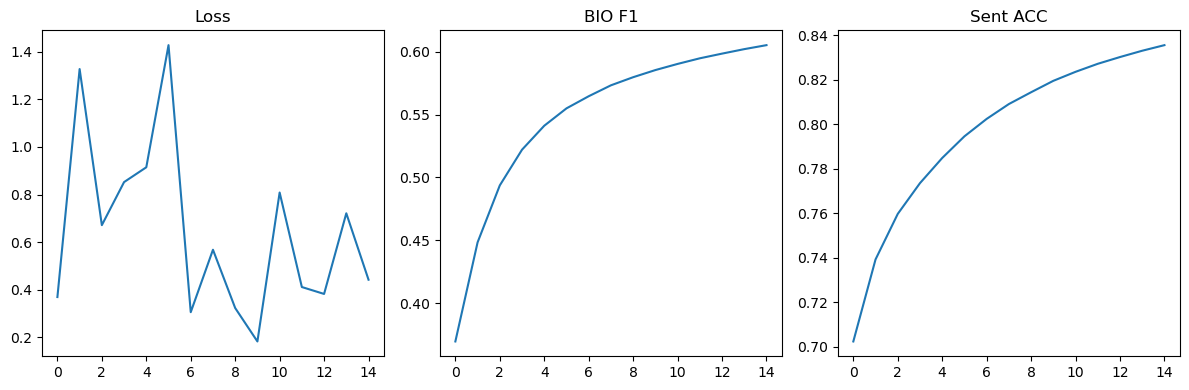

In [42]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.plot(h_losses); plt.title('Loss')
plt.subplot(1, 3, 2); plt.plot(h_f1s);    plt.title('BIO F1')
plt.subplot(1, 3, 3); plt.plot(h_accs);   plt.title('Sent ACC')
plt.tight_layout(); plt.show()

## XAI Visualization Modules

In [24]:
pip install lime

     ---------------------------------------- 0.0/275.7 kB ? eta -:--:--
     - -------------------------------------- 10.2/275.7 kB ? eta -:--:--
     ------------------- ------------------ 143.4/275.7 kB 2.1 MB/s eta 0:00:01
     -------------------------------------- 275.7/275.7 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283846 sha256=596492bbc8c4eb510a7d69b92d65688defadae5d70bad06c3bd69e661a9648ca
  Stored in directory: c:\users\98219\appdata\local\pip\cache\wheels\85\fa\a3\9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
Note: you may need to restart the kernel to use updated packages.


In [43]:
try:
    from lime.lime_text import LimeTextExplainer
except ImportError:
    print('LIME not installed; skipping LIME visualization.')

class WrappedSentModel(nn.Module):
    def __init__(self, base, head):
        super().__init__(); self.base = base.encoder; self.head = head
    def forward(self, input_ids, attention_mask):
        enc = self.base(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        pooled = (enc.last_hidden_state * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(1, keepdim=True)
        return torch.softmax(self.head.sent(pooled), dim=-1)
wrapped = WrappedSentModel(base, head).to(DEVICE)

# Saliency Visualization
def visualize_saliency(text, cls=0):
    toked = tok(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
    embeds = base.encoder.embed_tokens(toked['input_ids']); embeds.requires_grad_()
    enc = base.encoder(inputs_embeds=embeds, attention_mask=toked['attention_mask'], return_dict=True)
    pooled = (enc.last_hidden_state * toked['attention_mask'].unsqueeze(-1)).sum(1) / toked['attention_mask'].sum(1, keepdim=True)
    logits = head.sent(pooled); probs = torch.softmax(logits, dim=-1)
    score = probs[0, cls]; base.zero_grad(); head.zero_grad(); score.backward()
    grads = embeds.grad[0].abs().sum(dim=-1).cpu().numpy(); tokens = tok.convert_ids_to_tokens(toked['input_ids'][0])
    plt.figure(figsize=(10,4)); plt.bar(range(len(tokens)), grads); plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.title(f'Saliency (class={label_set[cls]})'); plt.tight_layout(); plt.show()

# Attention Visualization
def visualize_attention(text):
    toked = tok(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
    out = base.encoder(**toked, output_attentions=True, return_dict=True)
    matrix = out.attentions[-1][0].mean(0).cpu().numpy(); tokens = tok.convert_ids_to_tokens(toked['input_ids'][0])
    plt.figure(figsize=(10,8)); plt.imshow(matrix, interpolation='nearest')
    plt.xticks(range(len(tokens)), tokens, rotation=90); plt.yticks(range(len(tokens)), tokens)
    plt.title('Encoder Attention'); plt.colorbar(); plt.tight_layout(); plt.show()

In [44]:
# Corrected `visualize_attention` Function


def visualize_attention(text):
    """
    
    """
    # Tokenize input and move to device
    toked = tok(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
    
    # Forward without gradient tracking
    with torch.no_grad():
        out = base.encoder(
            **toked,
            output_attentions=True,
            return_dict=True
        )
    
    # Detach attention tensor before converting to numpy
    attn = out.attentions[-1][0].detach()   # shape: (seq_len, seq_len)
    matrix = attn.mean(0).cpu().numpy()     # Average over heads
    
    # Convert token IDs to token strings
    tokens = tok.convert_ids_to_tokens(toked['input_ids'][0])
    
    # Plot heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, interpolation='nearest')
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.title("Encoder Attention")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    #print("module complete")


## Run XAI Visualizations

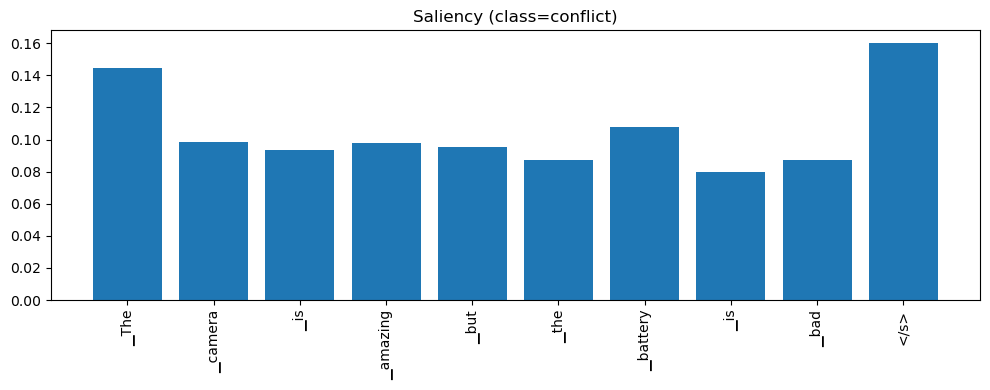

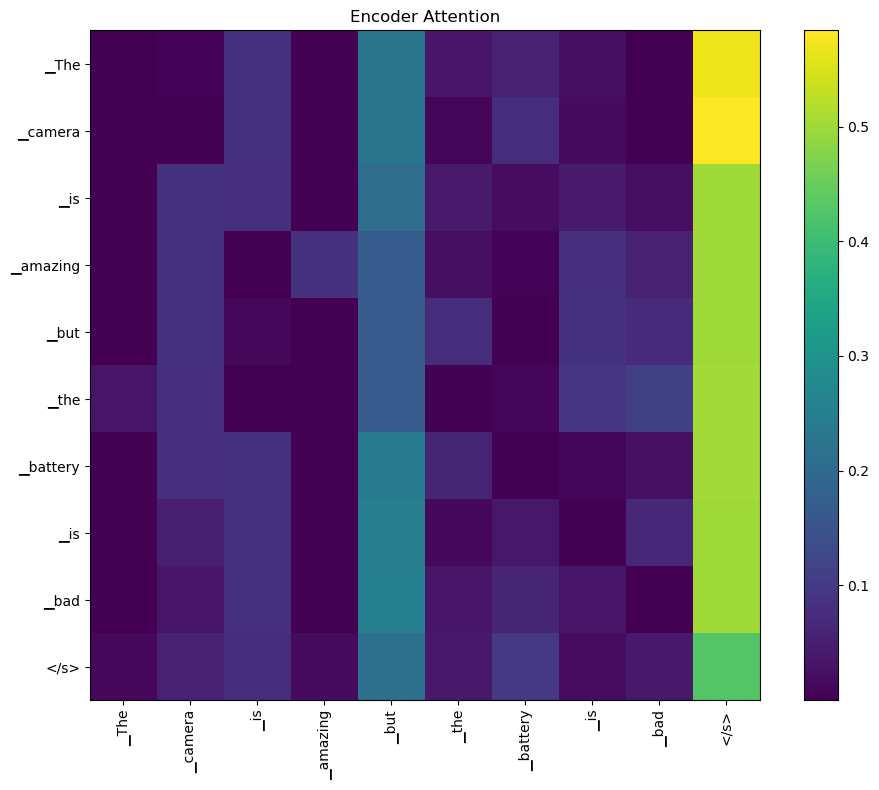

In [45]:
if ENABLE_XAI_VIS:
    test_sentence = "The camera is amazing but the battery is bad"
    visualize_saliency(test_sentence, cls=0)
    visualize_attention(test_sentence)

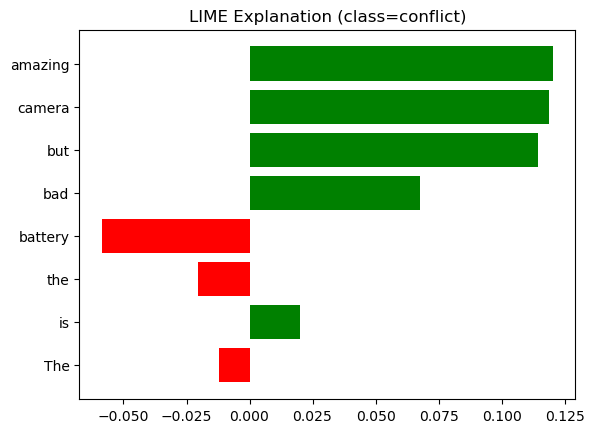

In [50]:
def visualize_lime(text, cls=0, num_features=10):
    """
    Use LIME to generate a local explanation for a single text instance. Skips if LIME is not installed.
    """
    # Check if the LIME explainer class is available
    if LimeTextExplainer is None:
        print("Skipping LIME visualization: lime module not detected.")
        return

    # Initialize the LIME text explainer with the sentiment class names
    explainer = LimeTextExplainer(class_names=label_set)

    # Define a helper function for LIME to get model probability predictions
    def predict_proba(texts):
        # Tokenize the input texts for the model, with padding and truncation
        toks = tok(
            texts,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=MAX_LEN
        ).to(DEVICE)
        with torch.no_grad():
            # Pass tokens through the wrapped model to obtain logits/probabilities
            out = wrapped(toks['input_ids'], attention_mask=toks['attention_mask'])
        # Move the output to CPU and convert to numpy array for LIME
        return out.cpu().numpy()

    # Generate a LIME explanation for the specified class label
    exp = explainer.explain_instance(
        text,
        predict_proba,
        num_features=num_features,
        labels=[cls]
    )
    # Create a matplotlib figure of the explanation
    fig = exp.as_pyplot_figure(label=cls)
    # Set the title to indicate which class is being explained
    plt.title(f"LIME Explanation (class={label_set[cls]})")
    plt.show()

# Example invocation: explain why the sentence is classified as the first sentiment class
test_sentence = "The camera is amazing but the battery is bad"
visualize_lime(test_sentence, cls=0)
